# Sweep 1 — Gemini blame vs the formal p0 curve

Overlays the live LLM run (`results/parsed_sweep1_p0_*.csv`) on the theoretical
Shapley p0 sweep from `framework/analysis.ipynb` (Sweep 1 baseline).

Each ordinal belief level is placed at its **oracle reference p0** so the LLM
points sit on the same x-axis as the theory curve. Theory is in absolute
Shapley units (left axis); the LLM rates 0-100 (right axis) — compare **shape**.

In [1]:
import sys, glob, os
sys.path.insert(0, '..')            # so `engine` is importable from analysis/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from engine import oracle
from engine.params import Cell

LEVEL_ORDER = ['very_low','low','somewhat_low','even','somewhat_high','high','very_high']
P0_REF = oracle.P0_REFERENCE        # ordinal id -> reference p0 (oracle-only)

path = sorted(glob.glob(os.path.join('..','results','parsed_sweep1_p0_*.csv')))[-1]
df = pd.read_csv(path)
n_err = df['error'].notna().sum()
df = df[df['error'].isna()].copy()
df['p0_ref'] = df['level'].map(P0_REF)
print(f'{os.path.basename(path)}  |  {len(df)} ok rows, {n_err} dropped  |  model={df["model"].iloc[0]}')

parsed_sweep1_p0_nemotron-3-nano-omni-30b-a3b-reasoning:free_20260529_235742.csv  |  314 ok rows, 1 dropped  |  model=nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free


In [2]:
# LLM blame per belief level: mean and 95% CI (1.96 * SE)
g = df.groupby('level', observed=True)['blameworthiness']
agg = pd.DataFrame({'mean': g.mean(), 'sem': g.std(ddof=1) / np.sqrt(g.size())}).reindex(LEVEL_ORDER)
agg['p0_ref'] = [P0_REF[l] for l in agg.index]
agg['ci'] = 1.96 * agg['sem']

# Theoretical Shapley curve on a fine p0 grid, using the SAME constants as the
# data file (engine.oracle), via the p0_value override. Baseline cell = vote no.
base = Cell(vote='no', c_sw='significant', alpha='modest', num_agents=7, pass_threshold=4)
p0_grid = np.linspace(0.05, 0.95, 60)
theory = np.array([oracle.oracle_blame(base, p0_value=x) for x in p0_grid])
peak_x = p0_grid[theory.argmax()]
agg

,mean,sem,p0_ref,ci
level,,,,
very_low,11.863636,0.834377,0.10,1.635379
low,16.133333,1.568181,0.20,3.073635
somewhat_low,22.866667,1.586432,0.35,3.109407
even,23.822222,1.937740,0.50,3.797971
somewhat_high,21.000000,1.723281,0.60,3.377631
high,14.688889,1.703775,0.80,3.339400
very_high,11.311111,1.483179,0.90,2.907031


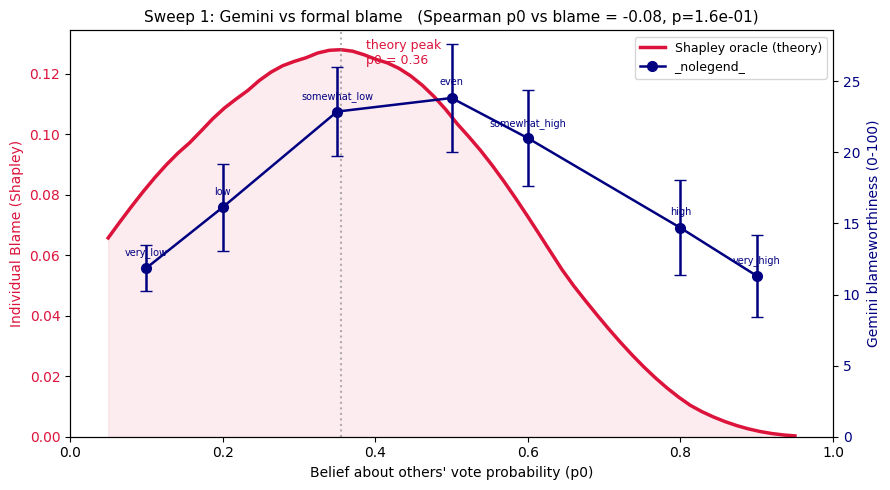

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

# Theory: crimson Shapley curve (framework Sweep-1 style)
ax.plot(p0_grid, theory, color='crimson', lw=2.5, label='Shapley oracle (theory)')
ax.fill_between(p0_grid, theory, alpha=0.08, color='crimson')
ax.axvline(peak_x, color='gray', ls=':', alpha=0.6)
ax.annotate(f'theory peak\np0 = {peak_x:.2f}', xy=(peak_x, theory.max()),
            xytext=(18, -10), textcoords='offset points', fontsize=9, color='crimson')
ax.set_xlabel("Belief about others' vote probability (p0)", fontsize=10)
ax.set_ylabel('Individual Blame (Shapley)', fontsize=10, color='crimson')
ax.tick_params(axis='y', labelcolor='crimson')
ax.set_xlim(0, 1); ax.set_ylim(bottom=0)

# LLM: navy points + 95% CI on a twin axis (0-100 scale)
axr = ax.twinx()
axr.errorbar(agg['p0_ref'], agg['mean'], yerr=agg['ci'], fmt='o-', color='navy',
             capsize=4, lw=1.8, ms=7, label='Gemini blameworthiness')
for l, r in agg.iterrows():
    axr.annotate(l, xy=(r['p0_ref'], r['mean']), xytext=(0, 9),
                 textcoords='offset points', ha='center', fontsize=7, color='navy')
axr.set_ylabel('Gemini blameworthiness (0-100)', fontsize=10, color='navy')
axr.tick_params(axis='y', labelcolor='navy')
axr.set_ylim(bottom=0)

rho, p = spearmanr(df['p0_ref'], df['blameworthiness'])
ax.set_title(f'Sweep 1: Gemini vs formal blame   (Spearman p0 vs blame = {rho:+.2f}, p={p:.1e})',
             fontsize=11)
lines = ax.get_lines()[:1] + axr.get_lines()[:1]
ax.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

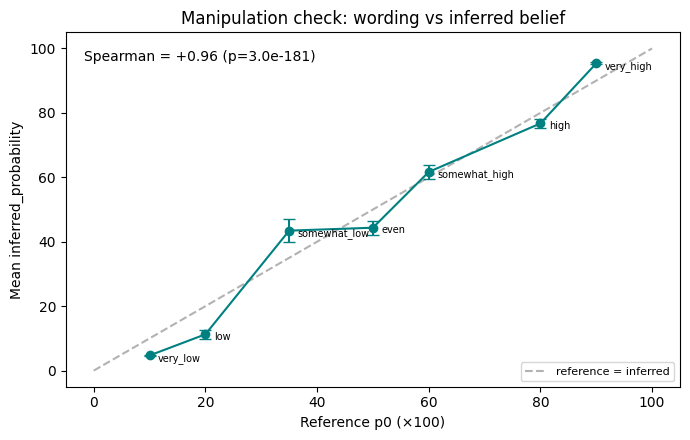

In [4]:
# Manipulation check: does each wording read as the intended belief?
# (mean inferred_probability vs the reference p0; dashed = identity)
gi = df.groupby('level', observed=True)['inferred_probability']
inf = pd.DataFrame({'mean': gi.mean(), 'sem': gi.std(ddof=1)/np.sqrt(gi.size())}).reindex(LEVEL_ORDER)
inf['p0_ref'] = [P0_REF[l] for l in inf.index]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot([0,100],[0,100], ls='--', color='gray', alpha=0.6, label='reference = inferred')
ax.errorbar(inf['p0_ref']*100, inf['mean'], yerr=1.96*inf['sem'], fmt='o-', color='teal', capsize=4)
for l, r in inf.iterrows():
    ax.annotate(l, xy=(r['p0_ref']*100, r['mean']), xytext=(6,-4), textcoords='offset points', fontsize=7)
ax.set_xlabel('Reference p0 (×100)'); ax.set_ylabel('Mean inferred_probability')
ax.set_title('Manipulation check: wording vs inferred belief'); ax.legend(fontsize=8)
rho, p = spearmanr(df['p0_ref'], df['inferred_probability'])
ax.text(0.03, 0.95, f'Spearman = {rho:+.2f} (p={p:.1e})', transform=ax.transAxes, va='top')
plt.tight_layout(); plt.show()

## Results (for gemini-2.0-flash-001)

1. **Main comparison plot** — mirrors the framework's Sweep-1 style: crimson Shapley curve vs p0 with the theory peak marked, and Gemini means (±95% CI) overlaid on a twin axis, each point placed at its reference p0.
2. **Manipulation-check plot** — mean `inferred_probability` vs reference p0 (with identity line), to confirm the wordings read as the intended belief.

### Headline finding

| level | p0 | LLM blame | inferred | oracle |
|---|---|---|---|---|
| very_low | 0.10 | 17.8 | 6.6 | 0.082 |
| low | 0.20 | 25.1 | 20.9 | 0.108 |
| somewhat_low | 0.35 | 30.2 | 33.1 | 0.128 |
| even | 0.50 | 27.2 | 47.1 | 0.106 |
| somewhat_high | 0.60 | 29.8 | 59.6 | 0.073 |
| high | 0.80 | 24.6 | 71.6 | 0.013 |
| very_high | 0.90 | 19.4 | 91.1 | 0.002 |

- **Manipulation check passes strongly**: `inferred_probability` tracks the intended ordinal almost perfectly (Spearman 0.98, nearly on the identity line). The number-free wordings do convey the intended belief — exactly the validation needed before trusting anything else.
- **The belief→blame result is the genuinely notable part**: Gemini's blame is non-monotonic and peaks at `somewhat_low` (p0 ≈ 0.35) — the same location as the formal Shapley peak — and falls off at both extremes. A flat/monotonic Spearman of 0.02 is not "no signal"; it's the signature of a symmetric hump, the strongest predicted Sweep-1 outcome (pivotality sensitivity), not the folk monotonic pattern.

> **Caveat**: This is a single-model, single-scenario read, so treat it as suggestive. The prompt's *"this belief accurately reflected the situation"* plus the explicit cost/lobbying sentences may be cueing structural reasoning — the s02/s03 scenarios and the `SECONDARY_AXIS` robustness check (e.g. repeat over vote) are the natural next steps to see if the hump survives.
